## Disaster tweets classification.

Dataset was sourced from kaggle - https://www.kaggle.com/competitions/nlp-getting-started
This python script builds and trains a series of models to predict if a disaster occurred based on X (Twitter) tweets

The dataset is also available on Github: https://github.com/laxmimerit/twitter-disaster-prediction-dataset/tree/master

This python script is a work in progress


In [1]:
# Import Libraries
import re
import string
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('ggplot')

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.optimizers import Adam


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\User\anaconda3\envs\tflowenv\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\User\anaconda3\envs\tflowenv\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\User\anaconda3\envs\tflowenv\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\User\anaconda3\envs\tflowenv\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.s

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\User\anaconda3\envs\tflowenv\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\User\anaconda3\envs\tflowenv\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\User\anaconda3\envs\tflowenv\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\User\anaconda3\envs\tflowenv\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.s

AttributeError: _ARRAY_API not found

ImportError: numpy.core._multiarray_umath failed to import

ImportError: numpy.core.umath failed to import

TypeError: Unable to convert function return value to a Python type! The signature was
	() -> handle

## Read in the data

In [22]:
# Below is a function to read in and create dataframes for the train and test data from my local drive.
# I have kept this code in but chose to not run it.
# I am obtaining the data from github, however, in case that data becomes unavailable, the below function is available to read in from my local drive where I have saved it
def load_from_drive():
    
    # Set the location to read the files
    base_path = "C:\\Users\\User\\Documents\\Python_Repositories\\NLP_Projects\\Disaster_Tweets\\"
    training_path = base_path + "train.csv"
    test_path = base_path + "test.csv"

    # Read in the train and test datasets and save these as dataframes
    tweet = pd.read_csv(training_path)
    tweet_test = pd.read_csv(test_path)

In [24]:
tweet = pd.read_csv('https://raw.githubusercontent.com/laxmimerit/twitter-disaster-prediction-dataset/refs/heads/master/train.csv')
tweet.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [25]:
# Check the number of rows and columns
tweet.shape

(7613, 5)

In [28]:
# Check null values
# some observations for keyword and location are missing
tweet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


## Exploratory data analysis

In [44]:
# Set default parameters for plots
plt.rcParams['figure.figsize'] = [8,4]
plt.rcParams['figure.dpi'] = 120

Target class distribution - check number of times the target was 1 (disaster) and 0 (not a disaster)

C:\Users\User\AppData\Local\Temp\ipykernel_10004\3396815826.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tweet, x = 'target', palette = "Set2")


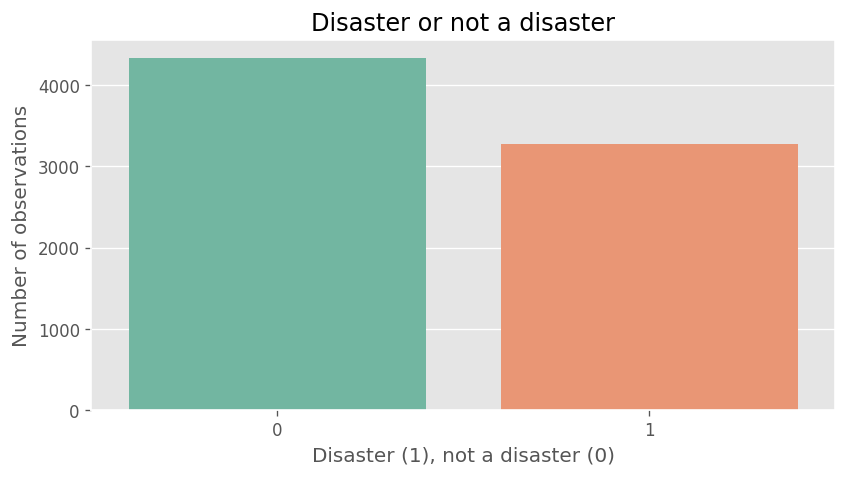

In [55]:
sns.countplot(data=tweet, x = 'target', palette = "Set2")
plt.title('Disaster or not a disaster')
plt.xlabel('Disaster (1), not a disaster (0)')
plt.ylabel('Number of observations')
plt.show()

In [46]:
# Check the actual number of observations for each of the target variable
tweet['target'].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

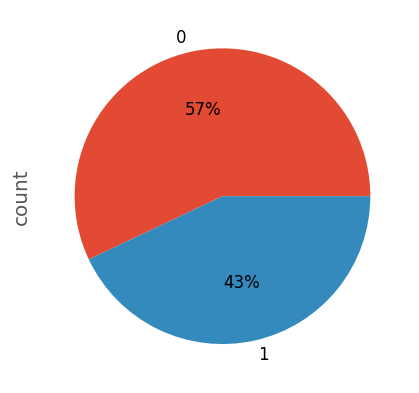

In [54]:
# Create a pie plot to check the proportion of observations in each target. Display as a percentage
tweet['target'].value_counts().plot.pie(autopct = '%1.f%%')
plt.show()

Number of characters in a tweet. Distribution in the number of characters

In [57]:
# Install pre-process package from git.
# This is available here: https://github.com/laxmimerit/preprocess_kgptalkie
!pip install git+https://github.com/laxmimerit/preprocess_kgptalkie.git

  Cloning https://github.com/laxmimerit/preprocess_kgptalkie.git to c:\users\user\appdata\local\temp\pip-req-build-34de0rns
  Resolved https://github.com/laxmimerit/preprocess_kgptalkie.git to commit 0f56a6502679f6750b7f0ffed98f590d1f0246bd
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/laxmimerit/preprocess_kgptalkie.git 'C:\Users\User\AppData\Local\Temp\pip-req-build-34de0rns'


In [2]:
import preprocess_kgptalkie as kgp